In [ ]:
# Install if needed
!pip install pandas numpy matplotlib seaborn scikit-learn

# Importing all libraries which needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Loading data set
df = pd.read_csv('/content/heart.csv')

# Preview
df.head()

,age,sex,chest_pain_type,resting_bp,cholestoral,fasting_blood_sugar,restecg,max_hr,exang,oldpeak,slope,num_major_vessels,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
# Data preparation
# Check missing values
print(df.isnull().sum())

# Features and target
X = df.drop('target', axis=1)   # target = heart disease (0/1)
y = df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling (important for many models)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

age                    0
sex                    0
chest_pain_type        0
resting_bp             0
cholestoral            0
fasting_blood_sugar    0
restecg                0
max_hr                 0
exang                  0
oldpeak                0
slope                  0
num_major_vessels      0
thal                   0
target                 0
dtype: int64


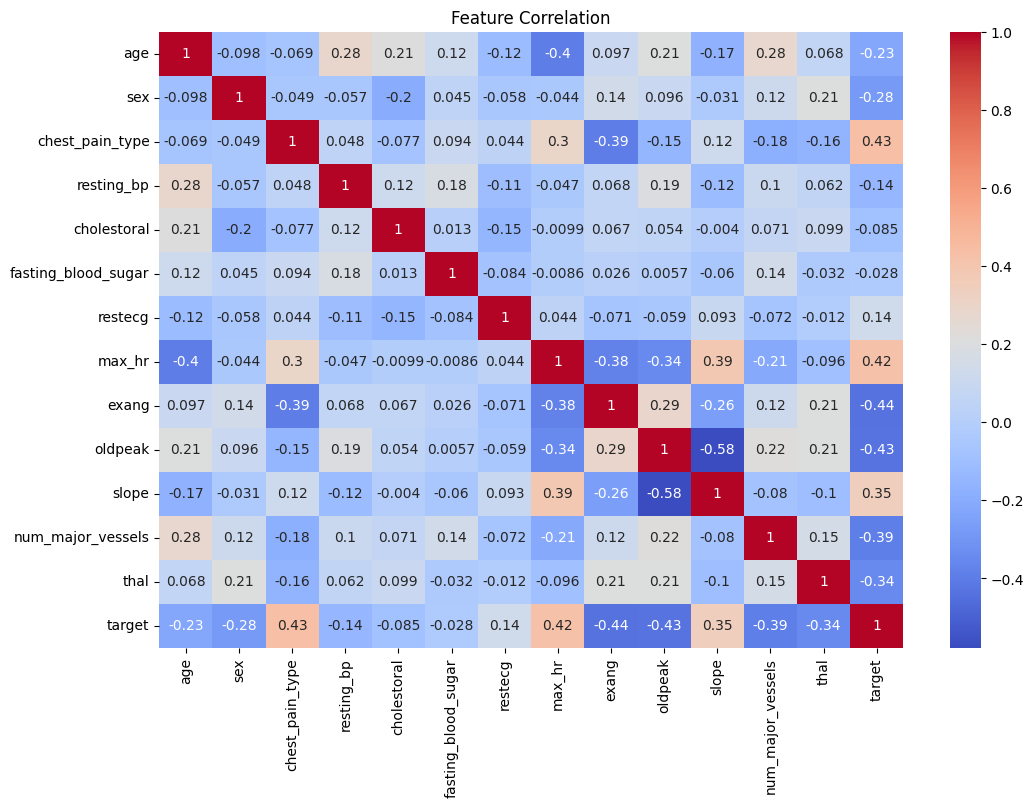

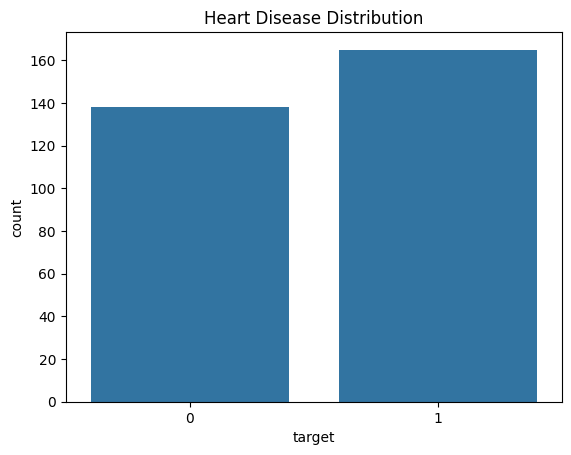

In [ ]:
# Data visualization
# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

# Target distribution
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

In [ ]:
# Train Classification Model
model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8524590163934426
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



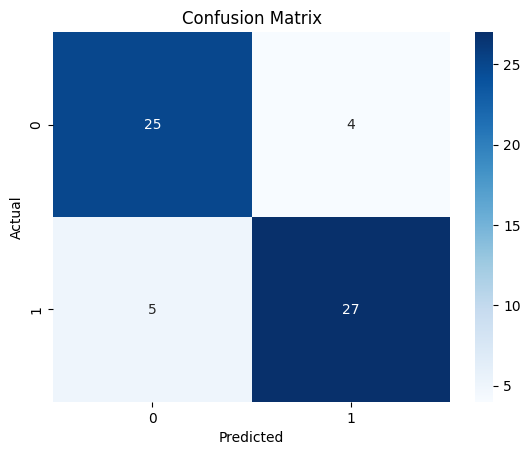

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# HYPERPARAMETER TUNING
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [4, 6, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, verbose=2)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)


Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END ..max_depth=4, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END ..max_depth=4, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END ..max_depth=4, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END ..max_depth=4, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END ..max_depth=4, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END .max_depth=4, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END .max_depth=4, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END .max_depth=4, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END .max_depth=4, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END .max_depth=4, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END .max_depth=4, min_samples_split=2, n_estimators=200; total time=   0.6s
[CV] END .max_depth=4, min_samples_split=2, n_es

In [ ]:
# EVALUATED TUNED MODEL
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_best))

Tuned Accuracy: 0.8852459016393442


In [ ]:
# TRACKING HYPERPARAMETER IMPACT
results = pd.DataFrame(grid.cv_results_)

# Show performance vs parameters
print(results[['params', 'mean_test_score']])

                                               params  mean_test_score
0   {'max_depth': 4, 'min_samples_split': 2, 'n_es...         0.814031
1   {'max_depth': 4, 'min_samples_split': 2, 'n_es...         0.818027
2   {'max_depth': 4, 'min_samples_split': 2, 'n_es...         0.805612
3   {'max_depth': 4, 'min_samples_split': 5, 'n_es...         0.809949
4   {'max_depth': 4, 'min_samples_split': 5, 'n_es...         0.809864
5   {'max_depth': 4, 'min_samples_split': 5, 'n_es...         0.809779
6   {'max_depth': 6, 'min_samples_split': 2, 'n_es...         0.797619
7   {'max_depth': 6, 'min_samples_split': 2, 'n_es...         0.809949
8   {'max_depth': 6, 'min_samples_split': 2, 'n_es...         0.805612
9   {'max_depth': 6, 'min_samples_split': 5, 'n_es...         0.813861
10  {'max_depth': 6, 'min_samples_split': 5, 'n_es...         0.793367
11  {'max_depth': 6, 'min_samples_split': 5, 'n_es...         0.809864
12  {'max_depth': 10, 'min_samples_split': 2, 'n_e...         0.793367
13  {'